In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 74.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=49a36fa22554c498205a298bfe58010656ff5fa30946b20bd957ae2b10c2ecc5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
def generate_quantum_random_bits(num_bits):
    """Generates a list of true random bits using quantum superposition."""
    qc = QuantumCircuit(num_bits, num_bits)
    for i in range(num_bits):
        qc.h(i)
        qc.measure(i, i)

    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    counts = job.result().get_counts(compiled)

    bitstring = list(counts.keys())[0][::-1]
    return [int(b) for b in bitstring]

--- BB84 Protocol Simulation WITH Attacker ---
Alice's bits:  [1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0]
Alice's bases: ['s', 's', 's', 's', 's', 's', 'd', 's', 's', 's', 's', 's']
Eve's bases:   ['d', 's', 's', 's', 'd', 'd', 'd', 'd', 's', 'd', 's', 's']
Bob's bases:   ['s', 'd', 's', 's', 's', 's', 'd', 'd', 's', 's', 'd', 'd']
--------------------------------------------------
Alice's sifted key: [1, 1, 1, 1, 0, 1, 1, 0]
Bob's sifted key:   [1, 1, 1, 1, 0, 1, 1, 0]
--------------------------------------------------
Total bits matching in basis: 8
Errors detected: 0
Error Rate: 0.00%

[?] No errors detected above threshold. (Eve got lucky guessing the bases).


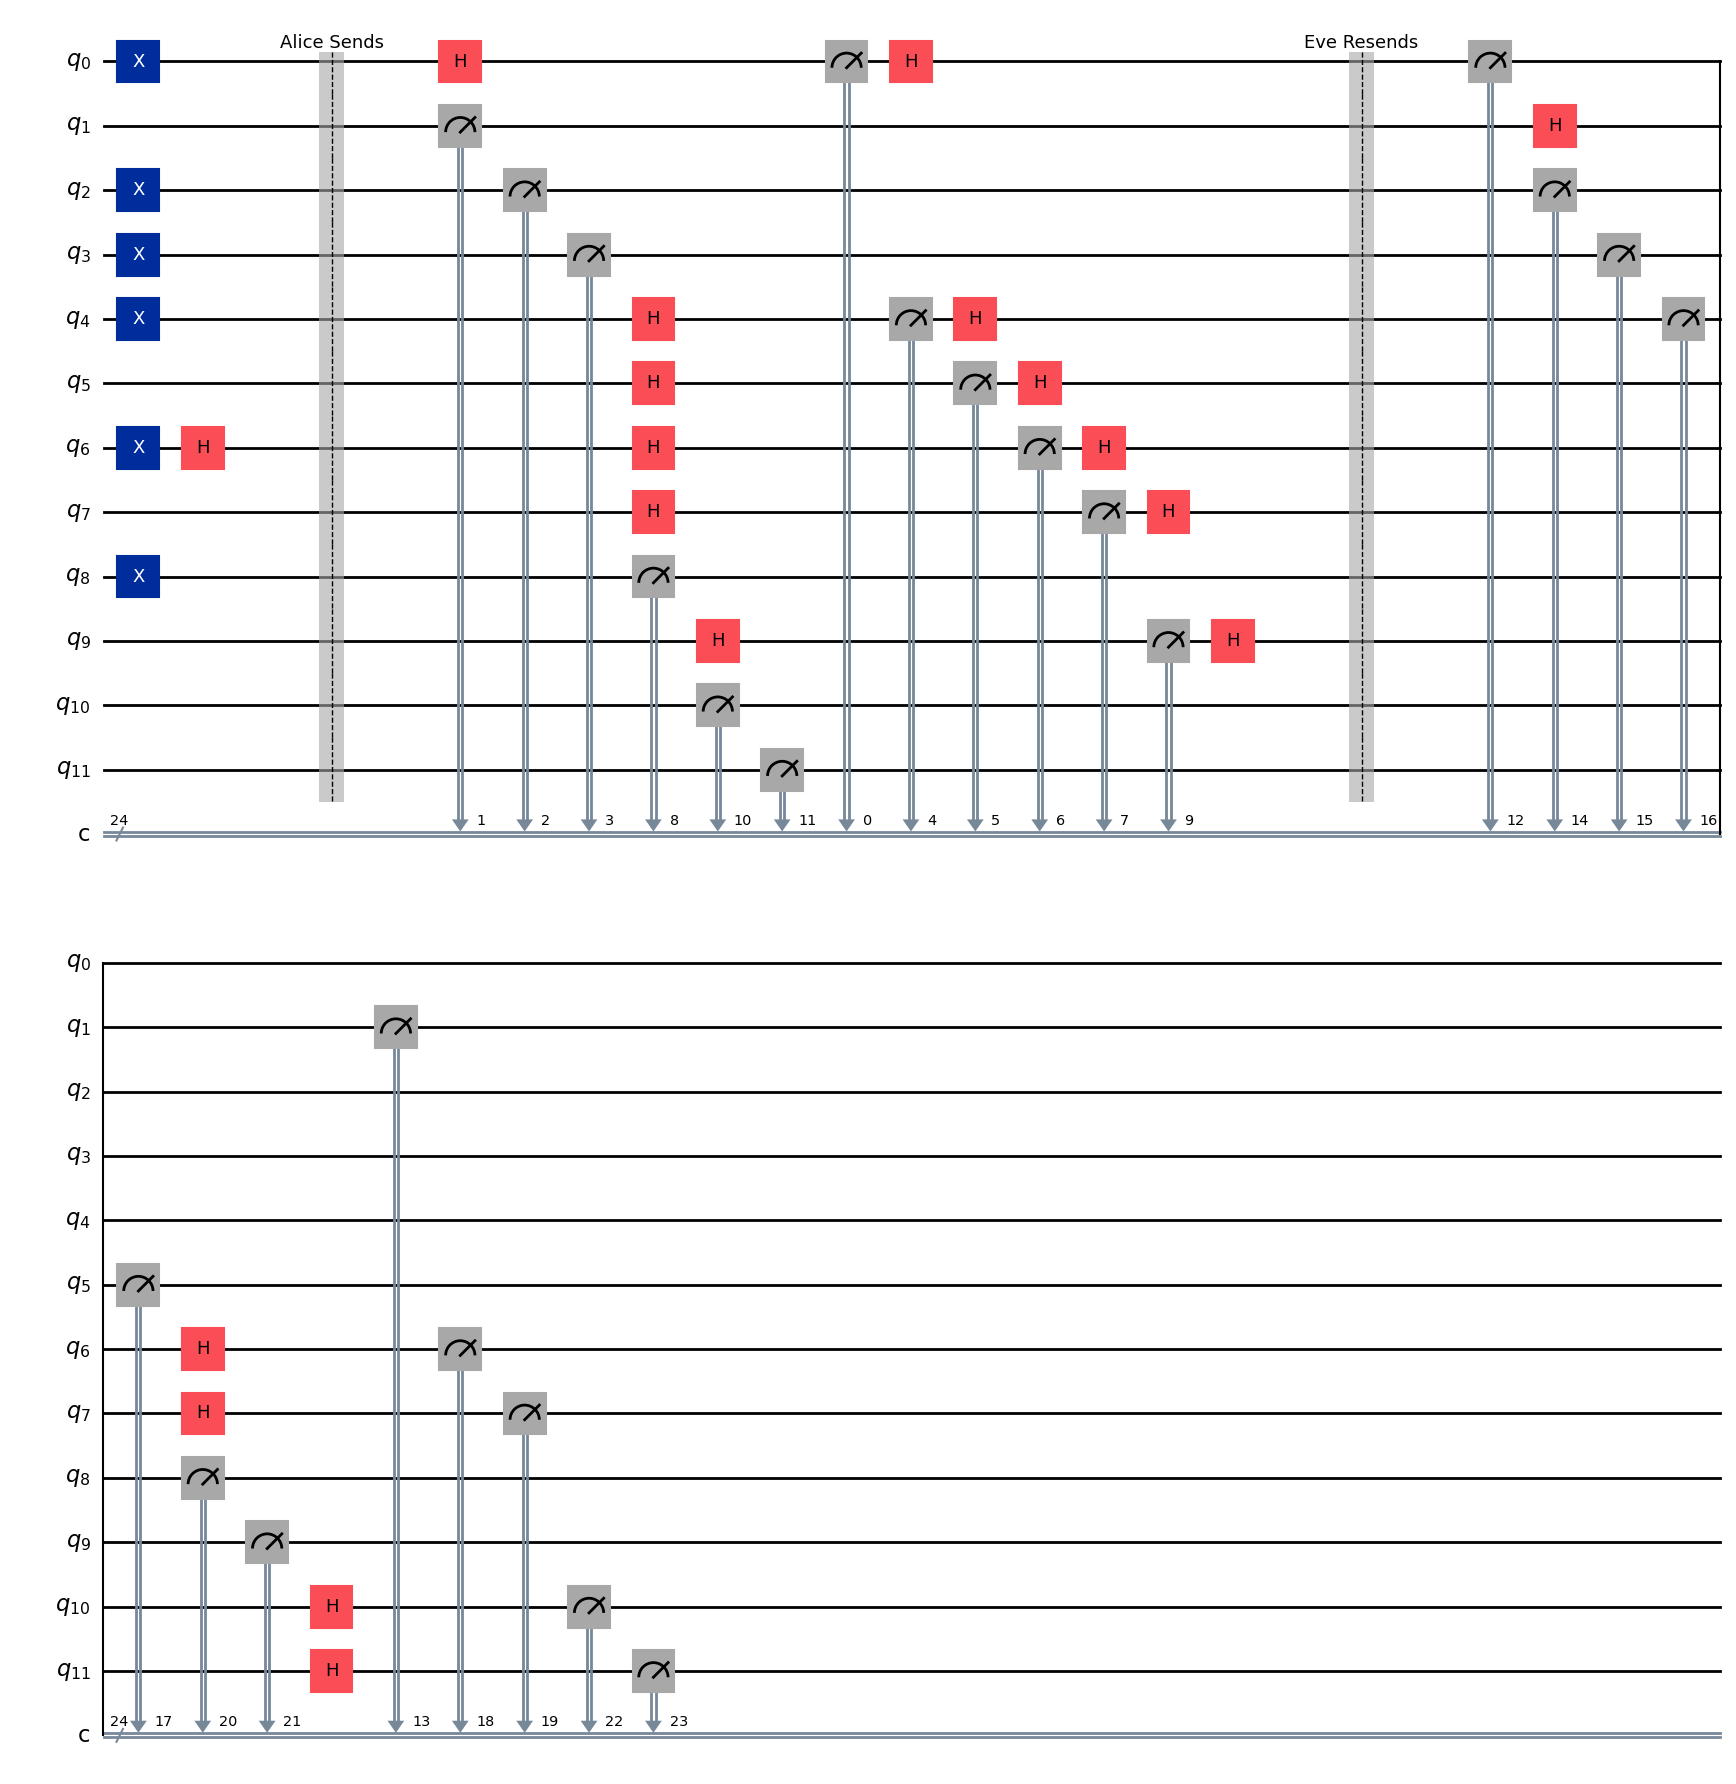

In [3]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

# Define the number of qubits to send
n = 12

# 1. Generate random bits and bases using the Quantum RNG
alice_bits = generate_quantum_random_bits(n)

alice_bases_raw = generate_quantum_random_bits(n)
alice_bases = ['d' if b == 1 else 's' for b in alice_bases_raw]

eve_bases_raw = generate_quantum_random_bits(n)
eve_bases = ['d' if b == 1 else 's' for b in eve_bases_raw]

bob_bases_raw = generate_quantum_random_bits(n)
bob_bases = ['d' if b == 1 else 's' for b in bob_bases_raw]

# Create a quantum circuit with n qubits and 2*n classical bits
bb84 = QuantumCircuit(n, 2 * n)

# ---------------------------------------------
# PHASE 1: Alice prepares her qubits
# ---------------------------------------------
for i in range(n):
    if alice_bits[i] == 1:
        bb84.x(i)
    if alice_bases[i] == 'd':
        bb84.h(i)

bb84.barrier(label="Alice Sends")

# ---------------------------------------------
# PHASE 2: Eve intercepts and measures
# ---------------------------------------------
for i in range(n):
    if eve_bases[i] == 'd':
        bb84.h(i)

    bb84.measure(i, i) # Eve's measurement

    # Eve resends to Bob (re-applying H if she measured in diagonal basis)
    if eve_bases[i] == 'd':
        bb84.h(i)

bb84.barrier(label="Eve Resends")

# ---------------------------------------------
# PHASE 3: Bob receives and measures
# ---------------------------------------------
for i in range(n):
    if bob_bases[i] == 'd':
        bb84.h(i)

    bb84.measure(i, i + n) # Bob's measurement

# ---------------------------------------------
# Simulate the communication circuit
# ---------------------------------------------
backend = BasicSimulator()
compiled = transpile(bb84, backend)
job_sim = backend.run(compiled, shots=1)
counts = job_sim.result().get_counts(compiled)

measured_str = list(counts.keys())[0][::-1]
eve_bits = [int(b) for b in measured_str[0:n]]
bob_bits = [int(b) for b in measured_str[n:2*n]]

# ---------------------------------------------
# PHASE 4: Sifting and Error Detection
# ---------------------------------------------
alice_key = []
bob_key = []

for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        alice_key.append(alice_bits[i])
        bob_key.append(bob_bits[i])

errors = sum([1 for a, b in zip(alice_key, bob_key) if a != b])
error_rate = (errors / len(alice_key)) * 100 if len(alice_key) > 0 else 0

# The participants check the threshold of disrupted qubits
ERROR_THRESHOLD = 0.0

print("--- BB84 Protocol Simulation WITH Attacker ---")
print(f"Alice's bits:  {alice_bits}")
print(f"Alice's bases: {alice_bases}")
print(f"Eve's bases:   {eve_bases}")
print(f"Bob's bases:   {bob_bases}")
print("-" * 50)
print(f"Alice's sifted key: {alice_key}")
print(f"Bob's sifted key:   {bob_key}")
print("-" * 50)
print(f"Total bits matching in basis: {len(alice_key)}")
print(f"Errors detected: {errors}")
print(f"Error Rate: {error_rate:.2f}%")

if error_rate > ERROR_THRESHOLD:
    print(f"\n[!] ALERT: Error rate of {error_rate:.2f}% exceeds the threshold of {ERROR_THRESHOLD}%.")
    print("    Eavesdropper presence confirmed! The protocol is aborted.")
else:
    print(f"\n[?] No errors detected above threshold. (Eve got lucky guessing the bases).")


bb84.draw("mpl")